In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("dirty_cafe_sales.csv")

In [3]:
df.replace(["ERROR", "UNKNOWN"], np.nan, inplace=True)

In [4]:
numeric_cols = ["Quantity", "Price Per Unit", "Total Spent"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [5]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_7575/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [6]:
encoder = LabelEncoder()

categorical_cols = ["Item", "Payment Method", "Location"]

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

In [7]:
X = df[["Item", "Quantity", "Price Per Unit", "Payment Method", "Location"]]

In [8]:
y = df["Total Spent"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [10]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [11]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [12]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [13]:
def evaluate_model(y_true, y_pred, model_name):

    print(f"\n{model_name}")

    print("MAE:", mean_absolute_error(y_true, y_pred))

    print("MSE:", mean_squared_error(y_true, y_pred))

    print("R2 Score:", r2_score(y_true, y_pred))

In [14]:
evaluate_model(y_test, lr_pred, "Linear Regression")

evaluate_model(y_test, dt_pred, "Decision Tree")

evaluate_model(y_test, rf_pred, "Random Forest")


Linear Regression
MAE: 2.046512332306614
MSE: 9.822773949517643
R2 Score: 0.7277701454290408

Decision Tree
MAE: 1.2284355927750203
MSE: 8.07986523757524
R2 Score: 0.7760733831520099

Random Forest
MAE: 1.2239279652906585
MSE: 7.473200126207997
R2 Score: 0.7928865925254058


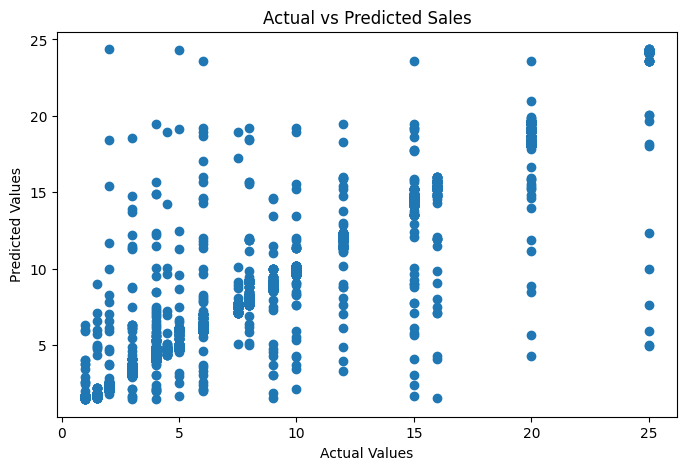

In [15]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted Sales")

plt.show()

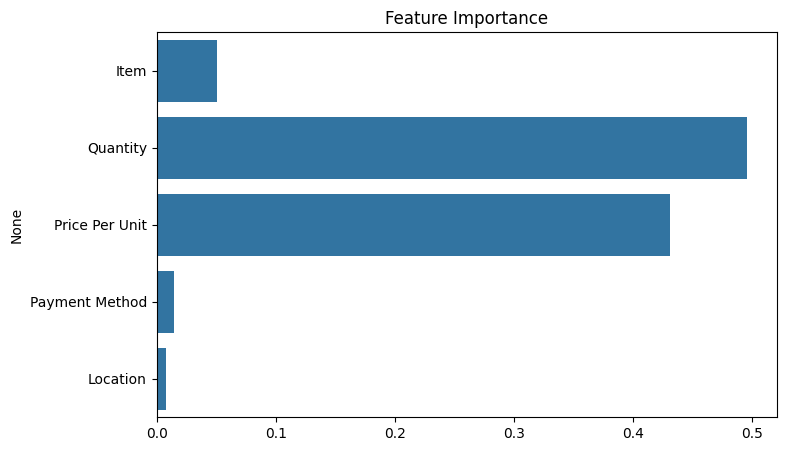

In [16]:
importance = rf.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))

sns.barplot(
    x=importance,
    y=features
)

plt.title("Feature Importance")

plt.show()